In [70]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [71]:
flat_chess = cv2.imread('../DATA/flat_chessboard.png')
flat_chess = cv2.cvtColor(flat_chess,cv2.COLOR_BGR2RGB)

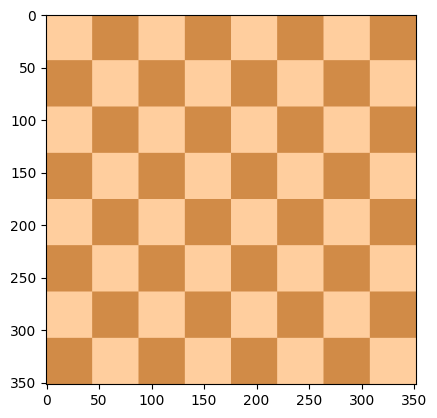

In [72]:
plt.imshow(flat_chess)

In [73]:
gray_flat_chess =  cv2.cvtColor(flat_chess,cv2.COLOR_RGB2GRAY)

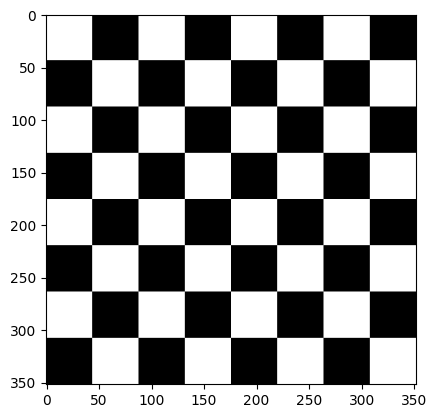

In [74]:
plt.imshow(gray_flat_chess,cmap='gray')

In [75]:
real_chess = cv2.imread('../DATA/real_chessboard.jpg')
real_chess = cv2.cvtColor(real_chess,cv2.COLOR_BGR2RGB)

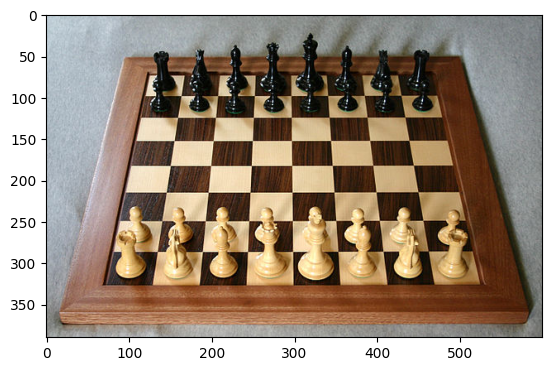

In [76]:
plt.imshow(real_chess)

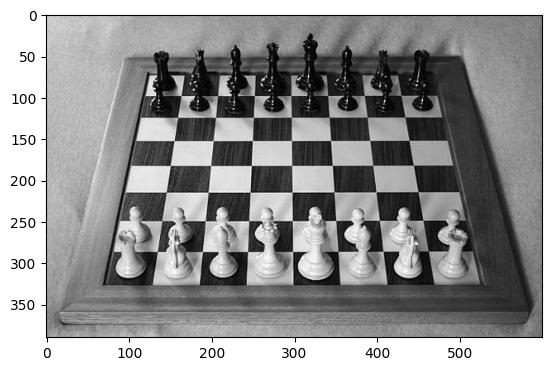

In [77]:
gray_real_chess = cv2.cvtColor(real_chess,cv2.COLOR_RGB2GRAY)
plt.imshow(gray_real_chess,cmap='gray')

In [78]:
gray = np.float32(gray_flat_chess)

In [79]:
gray

array([[215., 215., 215., ..., 152., 152., 152.],
       [215., 215., 215., ..., 152., 152., 152.],
       [215., 215., 215., ..., 152., 152., 152.],
       ...,
       [152., 152., 152., ..., 215., 215., 215.],
       [152., 152., 152., ..., 215., 215., 215.],
       [152., 152., 152., ..., 215., 215., 215.]],
      shape=(352, 352), dtype=float32)

In [80]:
dst = cv2.cornerHarris(gray,2,3,0.04)

In [81]:
dst = cv2.dilate(dst,None)
flat_chess[dst > 0.01 * dst.max()] = [255,0,0]

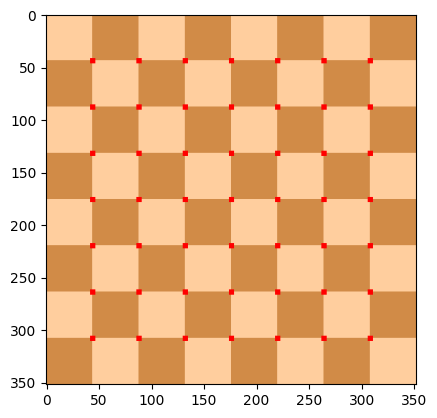

In [82]:
plt.imshow(flat_chess)

In [83]:
gray = np.float32(gray_real_chess)

dst = cv2.cornerHarris(gray,2,3,0.04)

dst = cv2.dilate(dst,None)

real_chess[dst > 0.01 * dst.max()] = [255,0,0]

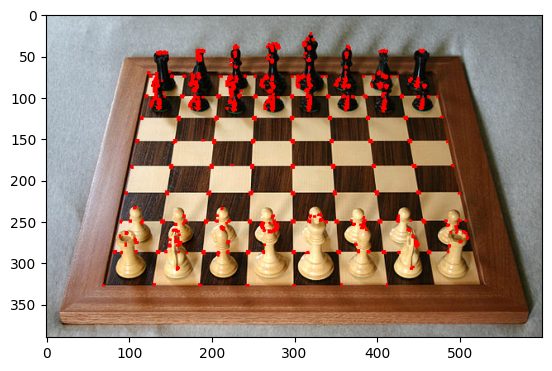

In [84]:
plt.imshow(real_chess)

In [85]:
flat_chess = cv2.imread('../DATA/flat_chessboard.png')
flat_chess = cv2.cvtColor(flat_chess,cv2.COLOR_BGR2RGB)

real_chess = cv2.imread('../DATA/real_chessboard.jpg')
real_chess = cv2.cvtColor(real_chess,cv2.COLOR_BGR2RGB)

gray_flat_chess =  cv2.cvtColor(flat_chess,cv2.COLOR_RGB2GRAY)
gray_real_chess = cv2.cvtColor(real_chess,cv2.COLOR_RGB2GRAY)

In [86]:
corners = cv2.goodFeaturesToTrack(gray_flat_chess,5,0.01,10) #default values # (img , max_corners , qualityLevel: float, minDistance)
# if put -1 on max_corner will return all corners

In [87]:
corners

array([[[308., 308.]],

       [[264., 308.]],

       [[220., 308.]],

       [[176., 308.]],

       [[132., 308.]]], dtype=float32)

In [89]:
corners = np.int16(corners)

In [90]:
corners

array([[[308, 308]],

       [[264, 308]],

       [[220, 308]],

       [[176, 308]],

       [[132, 308]]], dtype=int16)

In [91]:
for i in corners:
    x,y = i.ravel()
    cv2.circle(flat_chess,(x,y),3,(255,0,0),-1)

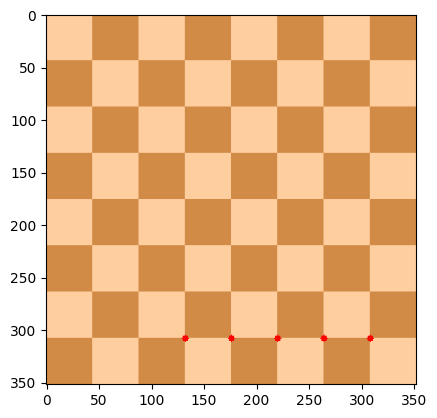

In [92]:
plt.imshow(flat_chess)

In [93]:
corners = cv2.goodFeaturesToTrack(gray_real_chess,10,0.01,10)

In [94]:
corners = np.int16(corners)

In [98]:
for i in corners:
    x,y = i.ravel()
    cv2.circle(real_chess,(x,y),3,(255,0,0),-1)

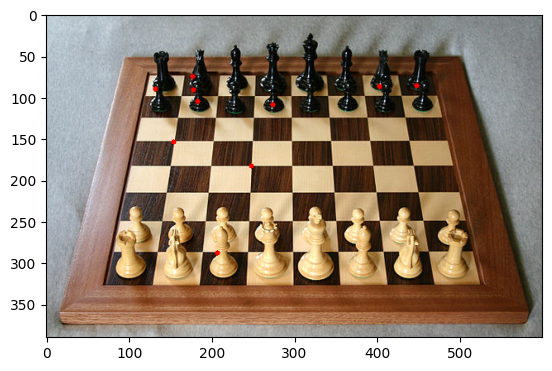

In [99]:
plt.imshow(real_chess)